Missing Values:
 Patient_ID        0
Age               0
Gender            0
Blood_Pressure    0
Sugar_Level       0
Cholesterol       0
Heart_Rate        0
dtype: int64

Statistics:
         Patient_ID           Age  Blood_Pressure   Sugar_Level   Cholesterol  \
count  10000.00000  10000.000000    10000.000000  10000.000000  10000.000000   
mean    5000.50000     50.290400      129.668100    135.618200    224.568500   
std     2886.89568     17.588957       29.138093     37.843946     43.604943   
min        1.00000     20.000000       80.000000     70.000000    150.000000   
25%     2500.75000     35.000000      104.000000    103.000000    187.000000   
50%     5000.50000     50.000000      130.000000    136.000000    224.000000   
75%     7500.25000     66.000000      155.000000    169.000000    262.000000   
max    10000.00000     80.000000      180.000000    200.000000    300.000000   

         Heart_Rate  
count  10000.000000  
mean      89.890900  
std       17.483803  
min    

/tmp/ipykernel_33210/3537001429.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_analysis = data.groupby("Age_Group")["Blood_Pressure"].mean()


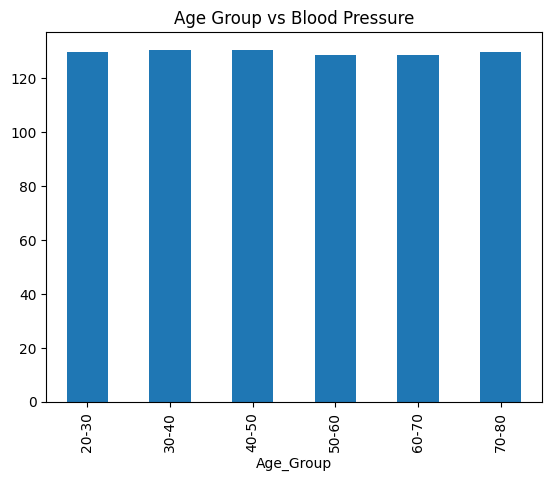

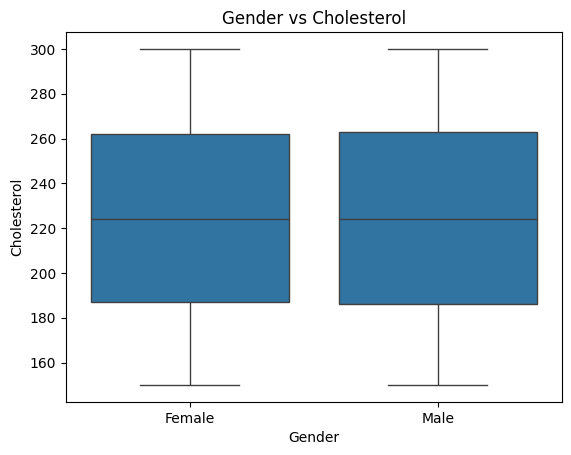

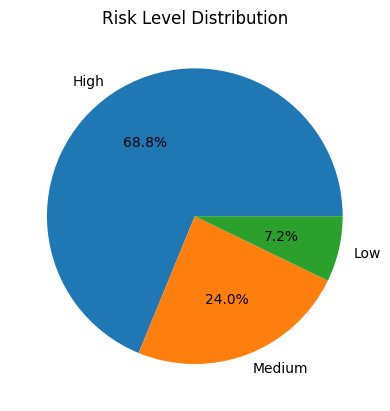

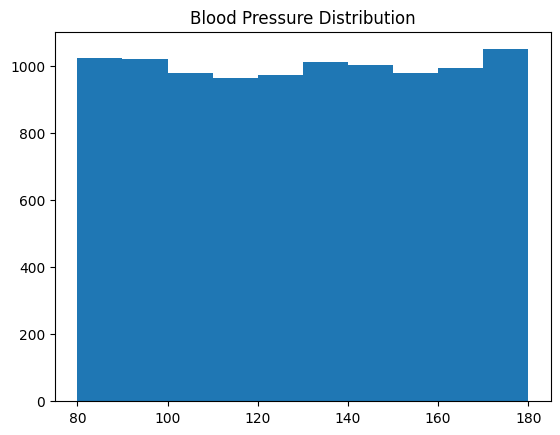

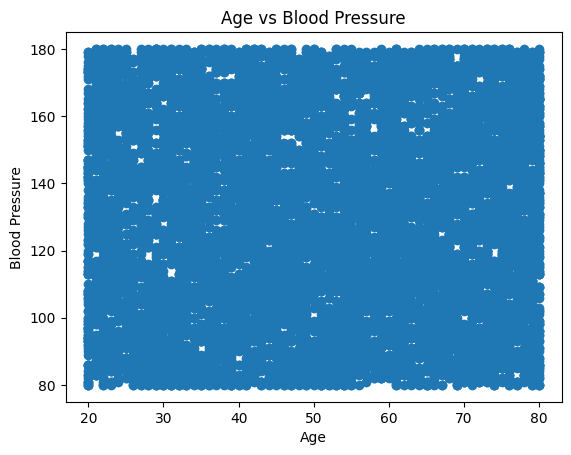

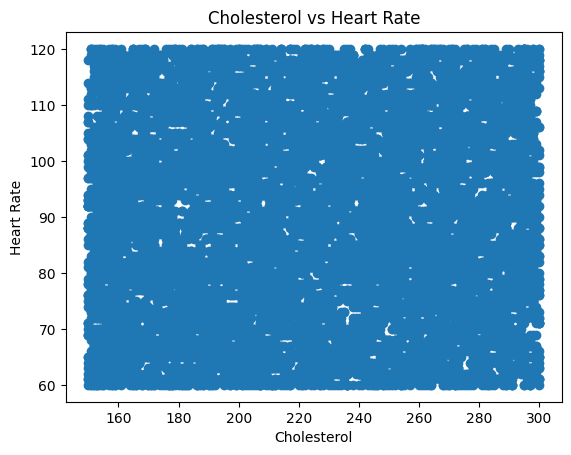

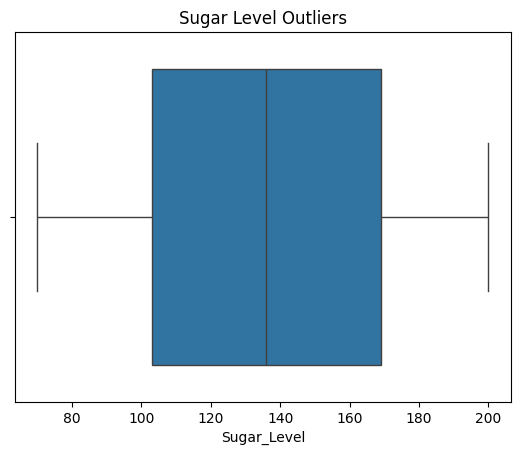

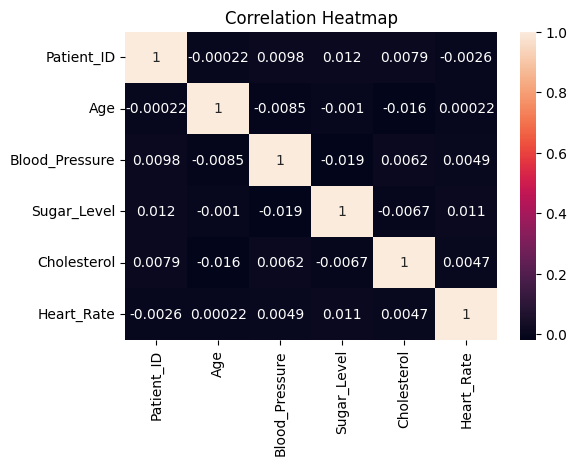


Analysis Completed Successfully ✅


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Synthetic Data
np.random.seed(42)

n = 10000

data = pd.DataFrame({
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 81, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Blood_Pressure": np.random.randint(80, 181, n),
    "Sugar_Level": np.random.randint(70, 201, n),
    "Cholesterol": np.random.randint(150, 301, n),
    "Heart_Rate": np.random.randint(60, 121, n)
})

# 2. Data Cleaning
print("Missing Values:\n", data.isnull().sum())

# 3. Risk Classification
def risk_level(row):
    if (row["Blood_Pressure"] > 140 or
        row["Sugar_Level"] > 180 or
        row["Cholesterol"] > 240):
        return "High"
    elif (row["Blood_Pressure"] > 120 or
          row["Sugar_Level"] > 140 or
          row["Cholesterol"] > 200):
        return "Medium"
    else:
        return "Low"

data["Risk"] = data.apply(risk_level, axis=1)

# 4. Descriptive Statistics
print("\nStatistics:\n", data.describe())

# 5. High Risk Patients
high_risk = data[data["Risk"] == "High"]
print("\nHigh Risk Patients Count:", len(high_risk))

# 6. Age Group Analysis
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ["20-30", "30-40", "40-50", "50-60", "60-70", "70-80"]
data["Age_Group"] = pd.cut(data["Age"], bins=bins, labels=labels)

age_group_analysis = data.groupby("Age_Group")["Blood_Pressure"].mean()
age_group_analysis.plot(kind='bar')
plt.title("Age Group vs Blood Pressure")
plt.show()

# 7. Gender-wise Comparison
sns.boxplot(x="Gender", y="Cholesterol", data=data)
plt.title("Gender vs Cholesterol")
plt.show()

# 8. Risk Distribution (Pie Chart)
risk_count = data["Risk"].value_counts()
plt.pie(risk_count, labels=risk_count.index, autopct='%1.1f%%')
plt.title("Risk Level Distribution")
plt.show()

# 9. Histograms
plt.hist(data["Blood_Pressure"])
plt.title("Blood Pressure Distribution")
plt.show()

# 10. Scatter Plots
plt.scatter(data["Age"], data["Blood_Pressure"])
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.title("Age vs Blood Pressure")
plt.show()

plt.scatter(data["Cholesterol"], data["Heart_Rate"])
plt.xlabel("Cholesterol")
plt.ylabel("Heart Rate")
plt.title("Cholesterol vs Heart Rate")
plt.show()

# 11. Boxplot (Outliers)
sns.boxplot(x=data["Sugar_Level"])
plt.title("Sugar Level Outliers")
plt.show()

# 12. Heatmap (Correlation)
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Save dataset
data.to_csv("healthcare_data.csv", index=False)

print("\nAnalysis Completed Successfully ✅")